# Credit Risk Model Validation

Independent validation of the final logistic regression model developed in `03_modeling.ipynb`.

Includes:
1. Reproduce the final model from raw data
2. Discrimination: ROC-AUC, KS, Gini
3. Calibration: Hosmer-Lemeshow test, calibration plot
4. Stability: PSI on predicted score and key features
5. Validation memo: approve / reject / approve-with-conditions

## 1. Imports and Configuration

In [10]:
from pathlib import Path
import sys
import importlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

import src.preprocessing
import src.features
import src.model
import src.validation
from src.data_loader import load_data

importlib.reload(src.preprocessing)
importlib.reload(src.features)
importlib.reload(src.model)
importlib.reload(src.validation)

<module 'src.validation' from 'c:\\Users\\htuns\\Desktop\\credit-risk-model\\src\\validation.py'>

In [11]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cs-training.csv"

TARGET = "SeriousDlqin2yrs"

BASELINE_FEATURES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
]

# Final feature set from 03_modeling.ipynb
FINAL_FEATURES = BASELINE_FEATURES + ["AnyPastDue"]

## 2. Reproduce Final Model from Raw Data

Re-runs the same load / split / preprocess / feature-engineering steps as `03_modeling.ipynb`, using the same random state(67), so the train/test split and final model are identical.

In [12]:
df = load_data(DATA_PATH)

train_df, test_df = src.preprocessing.split_data(df, test_size=0.2, random_state=67)

train_df = src.preprocessing.remove_invalid_ages(train_df)
test_df = src.preprocessing.remove_invalid_ages(test_df)

train_df = src.preprocessing.handle_sentinel_values(train_df)
test_df = src.preprocessing.handle_sentinel_values(test_df)

train_df, test_df = src.preprocessing.handle_debt_ratio_outlier(train_df, test_df)
train_df, test_df = src.preprocessing.handle_revolving_utilization_outlier(train_df, test_df)

train_df, test_df = src.preprocessing.impute_missing(train_df=train_df, test_df=test_df, col="MonthlyIncome")
train_df, test_df = src.preprocessing.impute_missing(train_df=train_df, test_df=test_df, col="NumberOfDependents")

train_features, test_features = src.features.create_train_test_features(train_df, test_df)

print(f"Train shape: {train_features.shape}")
print(f"Test shape:  {test_features.shape}")

Train shape: (119792, 44)
Test shape:  (29938, 44)


In [13]:
final_model = src.model.fit_logistic_model(train_features, TARGET, FINAL_FEATURES)

train_prob = src.model.predict_probabilities(final_model, train_features, FINAL_FEATURES)
test_prob = src.model.predict_probabilities(final_model, test_features, FINAL_FEATURES)

y_train = train_features[TARGET]
y_test = test_features[TARGET]

print("Reproduced model matches 03_modeling.ipynb final model.")

Reproduced model matches 03_modeling.ipynb final model.


## 3. Discrimination

Measures how well the model rank-orders risky vs. safe borrowers, independent of whether predicted probabilities are well-calibrated.

- **ROC-AUC**: probability a randomly chosen bad borrower is scored higher than a randomly chosen good borrower
- **KS**: maximum separation between cumulative good/bad distributions

In [14]:
train_metrics = src.model.evaluate_model(y_train, train_prob)
test_metrics = src.model.evaluate_model(y_test, test_prob)

train_gini = src.validation.calculate_gini(train_metrics["ROC-AUC"])
test_gini = src.validation.calculate_gini(test_metrics["ROC-AUC"])

print("Discrimination")
print("==============")
print(f"Train: {train_metrics} | Gini: {train_gini}")
print(f"Test:  {test_metrics} | Gini: {test_gini}")
print(f"ROC-AUC Train-Test Gap: {train_metrics['ROC-AUC'] - test_metrics['ROC-AUC']:.4f}")
print(f"KS Train-Test Gap: {train_metrics['KS'] - test_metrics['KS']:.4f}")

Discrimination
Train: {'ROC-AUC': 0.85543, 'KS': 0.55189} | Gini: 0.71086
Test:  {'ROC-AUC': 0.85676, 'KS': 0.5609} | Gini: 0.71352
ROC-AUC Train-Test Gap: -0.0013
KS Train-Test Gap: -0.0090


### Interpretation

Test ROC-AUC (0.857) and test KS (0.561) exactly match the valuess from the modeling notebook. The train/test gap is small and negative for both metrics (ROC-AUC: -0.0013, KS: -0.0090), consistent with the modeling notebook's findings and showing no evidence of overfitting.

## 4. Calibration

Measures whether predicted probabilities match observed default rates

Both the Hosmer-Lemeshow test and the calibration plot use the same decile binning (`src.validation.bin_by_decile`), so the test statistic and the plot describe the same groups.

In [15]:
hl_result = src.validation.hosmer_lemeshow_test(y_test, test_prob, n_bins=10)

print("Hosmer-Lemeshow Test (Test Set)")
print("================================")
print(f"Chi-square: {hl_result['chi_square']}")
print(f"Degrees of freedom: {hl_result['degrees_of_freedom']}")
print(f"p-value: {hl_result['p_value']}")
display(hl_result["table"])

Hosmer-Lemeshow Test (Test Set)
Chi-square: 32.7698
Degrees of freedom: 8
p-value: 0.0001


,bin,total,observed_events,expected_events,observed_nonevents,expected_nonevents
0,0,2994,10,24.569881,2984,2969.430119
1,1,2994,22,33.952568,2972,2960.047432
2,2,2994,29,41.798848,2965,2952.201152
3,3,2993,38,50.407261,2955,2942.592739
4,4,2994,50,61.296071,2944,2932.703929
5,5,2994,88,79.690921,2906,2914.309079
6,6,2993,128,117.983965,2865,2875.016035
7,7,2994,213,186.410137,2781,2807.589863
8,8,2994,356,319.354441,2638,2674.645559
9,9,2994,1046,1052.881390,1948,1941.118610


,bin,mean_predicted,observed_rate,total
0,0,0.008206,0.003340,2994
1,1,0.011340,0.007348,2994
2,2,0.013961,0.009686,2994
3,3,0.016842,0.012696,2993
4,4,0.020473,0.016700,2994
5,5,0.026617,0.029392,2994
6,6,0.039420,0.042766,2993
7,7,0.062261,0.071142,2994
8,8,0.106665,0.118904,2994
9,9,0.351664,0.349365,2994


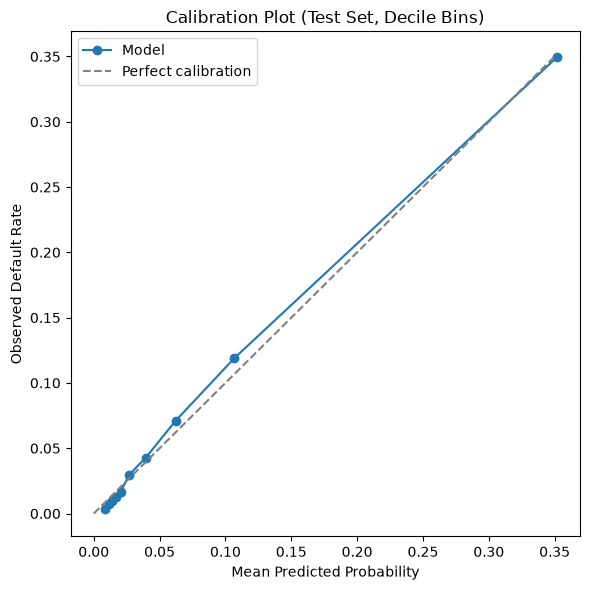

In [16]:
import os

FIGURES_DIR = Path.cwd().parent / "outputs" / "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)  # safe no-op if it already exists

calib_table = src.validation.calibration_table(y_test, test_prob, n_bins=10)
display(calib_table)

plt.figure(figsize=(6, 6))
plt.plot(calib_table["mean_predicted"], calib_table["observed_rate"], marker="o", label="Model")
plt.plot([0, calib_table["mean_predicted"].max()], [0, calib_table["mean_predicted"].max()],
         linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Plot (Test Set, Decile Bins)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "calibration_plot.png", dpi=150)
plt.show()

### Interpretation

The Hosmer-Lemeshow test rejects the null hypothesis of perfect calibration(p = 0.0001 < 0.05). Examining the bins and the graph, we see that the model has near-perfect calibraiton for higher risk borrowers, but tends to over predict default for middle risk borrowers. Additionallly, for lower risk borrowers, the model tends to under predict default. 

The magnitude of the errors is quite small(~1%) with bin 8, predicted 10.7% vs observed 11.9%, being the largest gap.

## 5. Stability

Population Stability Index (PSI) compares the train distribution (expected / development population) against the test distribution (actual / current population) for the predicted score and a small set of key features.

Standard thresholds:
```text
PSI < 0.10            no significant shift
0.10 <= PSI < 0.25    moderate shift, investigate
PSI >= 0.25           significant shift, model may need review
```

In [17]:
score_psi = src.validation.calculate_psi(train_prob, test_prob, n_bins=10)

print(f"Predicted Score PSI: {score_psi['psi']}")
display(score_psi["table"])

Predicted Score PSI: 0.00043


,bin,expected_pct,actual_pct,psi
0,"(-inf, 0.01]",0.100007,0.100307,9.023291e-07
1,"(0.01, 0.0127]",0.099998,0.100441,1.954488e-06
2,"(0.0127, 0.0154]",0.099998,0.101810,3.254283e-05
3,"(0.0154, 0.0185]",0.099998,0.099506,2.433430e-06
4,"(0.0185, 0.023]",0.099998,0.099873,1.570002e-07
5,"(0.023, 0.0321]",0.099998,0.103514,1.214734e-04
6,"(0.0321, 0.05]",0.099998,0.097936,4.298865e-05
7,"(0.05, 0.0771]",0.099998,0.095330,2.231541e-04
8,"(0.0771, 0.17]",0.099998,0.100508,2.588193e-06
9,"(0.17, inf]",0.100007,0.100775,5.879235e-06


In [18]:
KEY_STABILITY_FEATURES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "AnyPastDue",
    "DebtRatio",
]

feature_psi_results = {}

for feature in KEY_STABILITY_FEATURES:
    result = src.validation.calculate_psi(
        train_features[feature],
        test_features[feature],
        n_bins=10
    )
    feature_psi_results[feature] = result["psi"]
    print(f"{feature}: PSI = {result['psi']}")

RevolvingUtilizationOfUnsecuredLines: PSI = 0.00029
AnyPastDue: PSI = 0.0
DebtRatio: PSI = 0.00038


### Interpretation

"AnyPastDue" chosen as the engineered feature and the other 2 were chosen arbitrarily.
All PSI values are far below the 0.10 "no significant shift" threshold, for both the predicted score (0.00043) and the three key features examined (RevolvingUtilizationOfUnsecuredLines: 0.00029, AnyPastDue: 0.0, DebtRatio: 0.00038). 

This result makes sense because the training and testing sets are created from the same static dataset that doesn't move in time. You would most likely have to test this on historical data in order to get conclusive results.

## 6. Validation Memo

---

**Model:** Credit Risk Logistic Regression (Give Me Some Credit dataset)
**Validator:** Swan Htun
**Date:** 8/28/2026

### Scope

Validation covering discrimination, calibration, and stability. Model reproduced from original data, confirming pipeline is deterministic/reproducible. Benchmarking against a challenging model and/or historical data outside scope of this project.

### Summary of Findings

| Dimension | Metric | Result | Assessment |
|---|---|---|---|
| Discrimination | Test ROC-AUC | 0.857 | Strong |
| Discrimination | Test KS | 0.561 | Strong |
| Discrimination | Test Gini | 0.714 | Strong |
| Calibration | Hosmer-Lemeshow (χ², df, p) | 32.77, 8, 0.0001 | Statistically significant miscalibration; practically modest |
| Stability | Score PSI | 0.00043 | No shift detected (see limitation below) |
| Stability | Key feature PSI | RevolvingUtilizationOfUnsecuredLines: 0.00029, AnyPastDue: 0.0, DebtRatio: 0.00038 | No shift detected (see limitation below) |

### Discussion

The model discriminates strongly between good and bad borrowers (test ROC-AUC 0.857, KS 0.561), with a small train/test gap (-0.0013 AUC, -0.0090 KS) indicating no overfitting. 
Calibration testing rejects the null hypothesis of perfect fit (p = 0.0001), the decile breakdown shows a structured pattern:
risk is over-predicted in the lowest deciles and under-predicted in the middle-to-upper deciles, converging to near-exact calibration at the highest-risk decile, with a maximum gap of roughly 1.2 percentage points. 
Given the large test sample (n ≈ 29,938), the test has high power to detect even small deviations, so statistical significance here does not imply the probabilities are unusable. Stability metrics (PSI) show no shift between train and test, but this reflects the random samples coming from the same single static dataset. A more conclusive assessment would require time series data. 

### Recommendation

**[X] Approve with Conditions**

The model is approved for use in rank-based decisioning (accept/reject, risk tiering), where strong discrimination is the primary requirement. Before predicted probabilities are used directly in pricing, reserving, or other model applciations sensitive to the exact probability value, recalibration should be applied.